<a href="https://colab.research.google.com/github/yudadaniela/daniela-ai-projects/blob/main/clustering-votantes/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Nombre: Yurani Daniela Nieto Castro
###Machine learning, actividad # 4

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url="https://archive.ics.uci.edu/ml/machine-learning-databases/voting-records/house-votes-84.data"

COLUMNS=['PoliticalParty', 'Vote1', 'Vote2', 'Vote3', 'Vote4',
          'Vote5', 'Vote6', 'Vote7', 'Vote8', 'Vote9',
          'Vote10', 'Vote11', 'Vote12', 'Vote13', 'Vote14', 'Vote15','Vote16',]
df=pd.read_csv(url, header=None, names=COLUMNS)
df.head()

,PoliticalParty,Vote1,Vote2,Vote3,Vote4,Vote5,Vote6,Vote7,Vote8,Vote9,Vote10,Vote11,Vote12,Vote13,Vote14,Vote15,Vote16
0,republican,n,y,n,y,y,y,n,n,n,y,?,y,y,y,n,y
1,republican,n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,?
2,democrat,?,y,y,?,y,y,n,n,n,n,y,n,y,y,n,n
3,democrat,n,y,y,n,?,y,n,n,n,n,y,n,y,n,n,y
4,democrat,y,y,y,n,y,y,n,n,n,n,y,?,y,y,y,y


In [ ]:
print(df.shape)
print(df["PoliticalParty"].value_counts())

(435, 17)
PoliticalParty
democrat      267
republican    168
Name: count, dtype: int64


###Conclusión:
#####Hay 257 democratas y 168 republicanos, 435 filas y 17 columnas

In [ ]:
df.head()
print(df["Vote1"].value_counts())

Vote1
n    236
y    187
?     12
Name: count, dtype: int64


###Conclusión
#####Los valores no pueden ser letras tienen que ser numeros para el modelo ML

In [ ]:
df = df.replace({"y": 1, "n": 0})
df.head()

,PoliticalParty,Vote1,Vote2,Vote3,Vote4,Vote5,Vote6,Vote7,Vote8,Vote9,Vote10,Vote11,Vote12,Vote13,Vote14,Vote15,Vote16
0,republican,0,1,0,1,1,1,0,0,0,1,?,1,1,1,0,1
1,republican,0,1,0,1,1,1,0,0,0,0,0,1,1,1,0,?
2,democrat,?,1,1,?,1,1,0,0,0,0,1,0,1,1,0,0
3,democrat,0,1,1,0,?,1,0,0,0,0,1,0,1,0,0,1
4,democrat,1,1,1,0,1,1,0,0,0,0,1,?,1,1,1,1


###Conclusión:
#####Se cambiaron los valores a numéricos para que el modelo funcione correctamente, ya que los algoritmos de machine learning no pueden trabajar con texto, solo con números.

In [ ]:
print((df == "?").sum())

PoliticalParty      0
Vote1              12
Vote2              48
Vote3              11
Vote4              11
Vote5              15
Vote6              11
Vote7              14
Vote8              15
Vote9              22
Vote10              7
Vote11             21
Vote12             31
Vote13             25
Vote14             17
Vote15             28
Vote16            104
dtype: int64


En el dataset hay unos valores ?, los cuales podemos eliminar o reemplazar, pero analizando solo en la columnan vote16 hay 104, es mejor reemplazarlo

In [ ]:
df = df.replace("?", pd.NA)
df = df.fillna(df.mode().iloc[0])
print(df.isnull().sum())

PoliticalParty    0
Vote1             0
Vote2             0
Vote3             0
Vote4             0
Vote5             0
Vote6             0
Vote7             0
Vote8             0
Vote9             0
Vote10            0
Vote11            0
Vote12            0
Vote13            0
Vote14            0
Vote15            0
Vote16            0
dtype: int64


/tmp/ipykernel_2875/2116655171.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(df.mode().iloc[0])


##Coclusión:
##### Se reemplaza  ?, por la moda y despues observamos que no hay nulls

In [ ]:
y = df["PoliticalParty"]

X = df.drop("PoliticalParty", axis=1)

print(X.shape)
print(y.value_counts())

(435, 16)
PoliticalParty
democrat      267
republican    168
Name: count, dtype: int64


##Conclusión
#####En los modelos de clustering no se aceptan palabras o letras, ademas esta columna se guarda porque es la que nos dice la respuesta real, la vamos a guardar para despues compararla con los resultados.

In [ ]:
from sklearn.cluster import KMeans
model1= KMeans(n_clusters=2, random_state=42)
model1.fit(X)
#n_clusters=2 → porque son dos grupos
#random_state=42 → para que el resultado sea siempre igual, siempre empezara en el mismo punto
#fit(X) →  el modelo aprende, se le pasa los datos x y el busca los grupos mas parecidos entre si

KMeans(n_clusters=2, random_state=42)

##### Se propone el primer modelo con SKlearn, que es una librería usada ampliamente en el ML, el cluster es una tecnica en ML que se usa para agrupar los datos en función de similitudes, es de aprendizaje no supervisado, K-means divide los datos en grupos por cercania del centroide.  

In [ ]:
etiquetas = model1.labels_
print(etiquetas)

[0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 1 1 1 1 1 1 1 1 1 0 1 0 1 1 0 1 0 0
 0 0 1 1 1 1 1 1 1 1 1 1 0 1 0 1 0 1 0 0 0 0 0 1 0 1 1 1 0 0 0 1 1 1 1 1 0
 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 0 1 0 0 1 1 1 1 1 0 0 0 0 0 1 1 1 1 0 0 1 1 1 0 1
 0 1 0 0 1 1 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 0 1 0 0 1 1 1 0 1 0 1 1 1 1 1 1 0 1 0 0 1 1 1 0 1 1 0 0 1 0 1 1 1 1
 1 0 0 0 1 1 0 0 0 0 1 0 1 0 1 1 1 0 0 1 0 1 1 1 1 0 1 1 0 0 1 0 1 1 0 0 1
 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0
 0 1 1 1 0 1 0 0 0 0 0 1 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0 1 0 0 1 0 1 1 0 1 1
 1 1 0 1 1 1 0 0 1 1 0 1 0 0 0 1 0 1 0 1 0 1 1 0 0 1 0 1 1 1 0 0 0 1 1 1 0
 1 1 0 0 0 0 1 0 0 0 1 1 0 1 0 0 1 1 0 1 0 1 0 1 0 1 1 0 1 0 0 0 1 0 0 0 0
 0 1 0 0 1 0 0 1 1 0 1 1 1 0 1 1 1 1 1 1 0 1 1 0 1 0 0 0]


##### Los .labels_ son los grupos asignados por el modelo a cada congresista, ya sea 0 o 1

In [ ]:
df["cluster_kmeans"] = etiquetas
print(pd.crosstab(df["PoliticalParty"], df["cluster_kmeans"]))

cluster_kmeans    0    1
PoliticalParty          
democrat         41  226
republican      157   11


##### Agrega una columna nueva al dataframe llamada cluster_kmeans con los grupos que el modelo asigno del 1 y 0
##### crosstab hace una tabla cruzada, como el modelo lo partio en dos grupos entonces la political party con el modelo cluster_kmeans, para comparar los grupos que encontró el modelo con los partidos reales y ver qué tan bien clasificó.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

centroides_pca = pca.transform(model1.cluster_centers_)

print(centroides_pca)
print(X_pca.shape)
#fit → aprende cómo comprimir las 16 columnas a 2
#transform → aplica esa compresión a los datos

[[ 1.323318   -0.00563476]
 [-1.10555681  0.00470752]]
(435, 2)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


#####El problema es que tenemos 16 dimensiones y no lo podemos graficar, asi que usamos el PCA que reduce los datos a 2 dimensiones para poder graficarlos.
#####Los centroides también están en 16 dimensiones, entonces hay que comprimirlos también a 2 para graficarlos.

#####

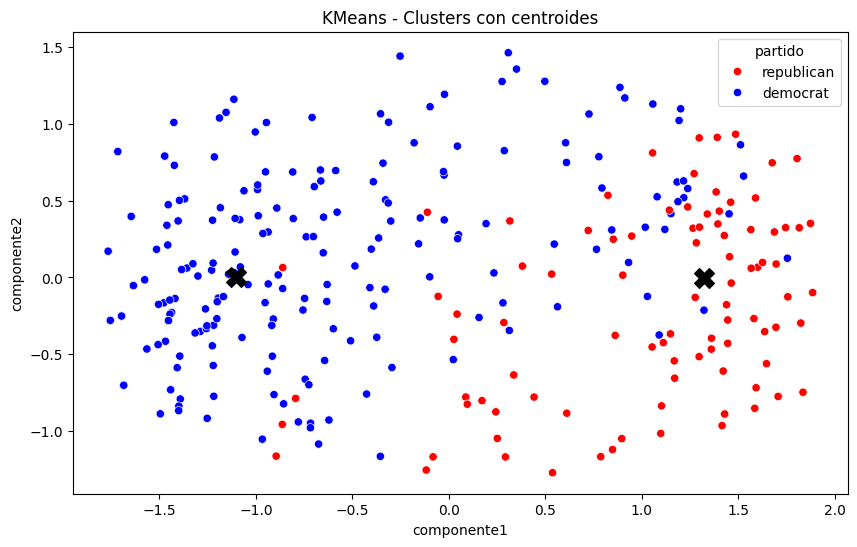

In [ ]:

import seaborn as sns

df_pca = pd.DataFrame(X_pca, columns=["componente1", "componente2"])
# Crea un nuevo dataframe con los datos reducidos a 2 dimensiones por PCA
# Las columnas se llaman componente1 y componente2
df_pca["cluster"] = etiquetas
# Agrega una columna con los grupos asignados por K-Means (0 o 1)
df_pca["partido"] = y.values
# Agrega una columna con los partidos reales (democrat/republican)

plt.figure(figsize=(10, 6))
# Crea el lienzo de la gráfica con tamaño 10 de ancho y 6 de alto
sns.scatterplot(data=df_pca, x="componente1", y="componente2",
                hue="partido", palette={"democrat":"blue", "republican":"red"})
# Grafica cada congresista como un punto
# hue="partido" colorea cada punto según su partido real

plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1],
            c="black", marker="X", s=200, label="Centroides")
# Agrega los centroides como puntos negros en forma de X
# [:, 0] = coordenada componente1 de cada centroide
# [:, 1] = coordenada componente2 de cada centroide
# s=200 = tamaño grande para que sean visibles

plt.title("KMeans - Clusters con centroides")
plt.show()

##Conclusión
##### El modelo hizo agrupaciones de datos semejantes basándose en unas votaciones,  clasifico correctamente el 88% de los congresistas. En la gráficas se ven dispersos, especialmente los republicanos que al ser menos puntos estan mas separados entre sí, el centroide es el centro de esas agrupaciones, es el congresista promedio del grupo.

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan.fit(X)

print(dbscan.labels_)
print(pd.Series(dbscan.labels_).value_counts())

[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0 -1  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1
  0 -1  0  0 -1 -1 -1 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0 -1  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1
 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0
  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0 -1  0  0 -1  0  0  0 -1  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0 -1  0  0  0  0  0  0  0  0  0 -1  0  0

##### DBSCAN necesita dos parametros eps que es el radio de búsqueda, que tan cerca deben estar los puntos para ser vecinos, mim_samples es cuantos vecinos minimo necesita un punto para formar un grupo.
##### 400 puntos en el grupo 0, 35 puntos marcados como ruido (-1),
#####1 solo grupo


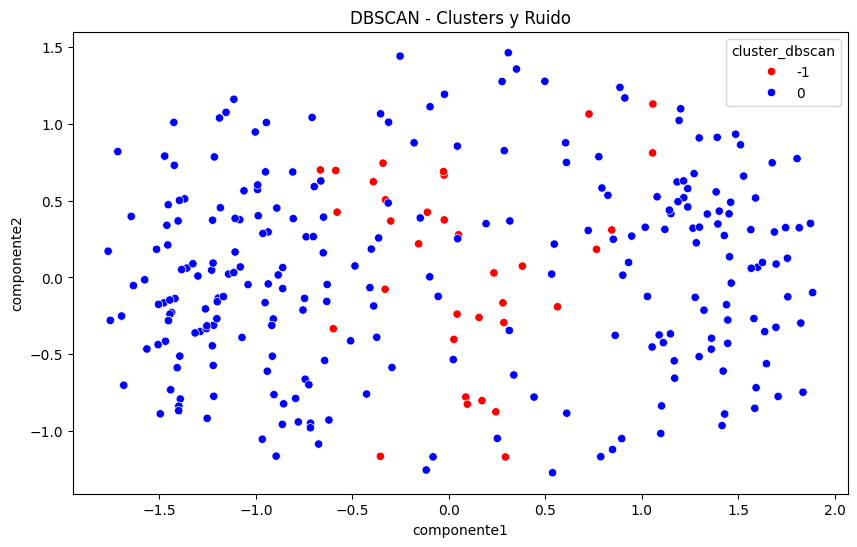

In [ ]:
df_pca["cluster_dbscan"] = dbscan.labels_

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca, x="componente1", y="componente2",
                hue="cluster_dbscan",
                palette={0: "blue", -1: "red"})
plt.title("DBSCAN - Clusters y Ruido")
plt.show()

##Conclusión
#####K-Means encontró dos grupos, a diferencia de DBSCAN que identificó solo uno. K-Means fue más preciso clasificando correctamente el 88% de los datos. Comparando ambas gráficas, los puntos de ruido de DBSCAN corresponden a los puntos más alejados de los centroides en K-Means, es decir, son congresistas que no votan igual que su grupo. DBSCAN identificó 35 congresistas atípicos que no encajan claramente en ningún grupo, algo que K-Means no hace ya que fuerza a cada punto a pertenecer a un grupo aunque no encaje. En general, K-Means mostró una mejor separación para estos datos, posiblemente porque conocíamos de antemano el número de grupos.